$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{April 10, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 9: Linear Regression}
\end{array}
$$

![Linear Regression](../figures/LR_lab9_image1.png)

---

# Recitation: Univariate Time Series

## Today's Outline

1. **What is Time Series Data?** — How it differs from cross-sectional and panel data; the forecasting motivation
2. **The AR(1) Model** — Definition, interpretation of ρ₁, stable vs unstable vs random walk
3. **Time Series Models are Structural** — Why misspecification matters more here than in predictive regression
4. **AR(1) Simulations** — Visualizing what different values of ρ₁ look like in practice
5. **Inflation as AR(1)** — Estimating ρ̂₁ = 0.79 on real US inflation data
6. **Forecasting** — Deriving E[Yt+h | Yt] and Var(Yt+h | Yt); the inflation fan chart
7. **Stationarity** — Definition, intuition, and why stable AR(1) satisfies it
8. **Weak Dependence** — Definition, proof that AR(1) satisfies it, why it replaces i.i.d.
9. **OLS Estimation of AR(1)** — 4 conditions, demeaning, and why it works
10. **Trending** — NASDAQ example, detrending, AR(1) with a trend term

---

## What is Time Series Data?

So far in this course, we've mostly worked with **cross-sectional data** — a snapshot of many 
units (people, firms, countries) at a single point in time. Time series data is fundamentally 
different.

**Time series data** tracks the values of a variable over time. The key distinction:

| | Cross-Sectional | Panel | Time Series |
|---|---|---|---|
| Units | Many | Many | One |
| Time periods | One | Many | Many |
| Dataset size comes from | # of units | # of units × # of periods | # of time periods |

With time series, there is in effect **just one unit of observation** — we see it repeatedly 
across time. Think of US inflation: there is one US economy, and we observe its inflation rate 
year after year.

---

### Why Does This Matter?

The "one observation" nature of time series changes where **randomness** comes from. 

- In cross-sectional data, randomness comes from *random sampling* — we draw different people 
  from a population
- In time series, randomness comes from *idiosyncratic period-to-period shocks* — the same 
  economy experiences different surprises each year

---

### What Is Time Series Used For?

The main application is **forecasting** — predicting future values of a variable based on its 
current and past values. Examples:

- *Policy*: If inflation is high this month, what will it be next month?
- *Public health*: If Covid prevalence is at X this year, what will it be next year?
- *Finance*: If a stock is at price P today, what will it be tomorrow?

---

## The AR(1) Model

The workhorse model of univariate time series analysis is the **autoregressive model of order 
one**, or **AR(1)**:

$$Y_t = \rho_1 Y_{t-1} + \varepsilon_t$$

where:
- $Y_t$ is the outcome of interest in period $t$
- $Y_{t-1}$ is its value in the previous period
- $\varepsilon_t$ is a **contemporaneous shock** — assumed i.i.d., so $\varepsilon_t \perp \varepsilon_{t+h}$ for any $h \neq 0$
- By convention, the first observed period is $t = 0$

The model says: **today's value is a linear function of yesterday's value, plus a random shock.**

---

### The Role of ρ₁ — Sign

| Value of ρ₁ | Interpretation |
|---|---|
| ρ₁ = 0 | No relationship between past and present — knowing yesterday tells you nothing |
| ρ₁ > 0 | Positive persistence — high values today → high values tomorrow (e.g. inflation) |
| ρ₁ < 0 | Mean reversion with oscillation — high values today → low values tomorrow (e.g. predator-prey cycles) |

### The Role of ρ₁ — Magnitude

| Value of ρ₁ | Behavior | Name |
|---|---|---|
| $\|\rho_1\| < 1$ | Shocks **fade out** over time | Stable process |
| $\|\rho_1\| > 1$ | Shocks **explode** over time | Unstable process |
| $\|\rho_1\| = 1$ | Shocks **persist forever** — neither fade nor explode | Random walk / Unit root |

---

### Generalizing: AR(p)

An AR(1) is the simplest member of a family of AR models. An **AR(3)**, for instance, would be:

$$Y_t = \rho_1 Y_{t-1} + \rho_2 Y_{t-2} + \rho_3 Y_{t-3} + \varepsilon_t$$

We focus on AR(1) because it captures most of the intuition and is the simplest to work with. 
But if $Y_t$ depends on periods further back than just $t-1$, an AR(1) would be **misspecified** 
— which brings us to the next point.

## Time Series Models are Structural

At this point in the course, we've seen two broad philosophies for building regression models:

**Descriptive/Predictive models** — the goal is to capture an aspect of a joint distribution 
or predict $Y$ as accurately as possible. We don't claim the model is literally "true" — just 
useful. If it's slightly misspecified, predictions degrade a little but we're not telling a 
wrong story about the world.

**Causal models** — we claim the model reflects a real mechanism in the world. 
Misspecification means we're estimating the wrong thing and interpreting it incorrectly.

**Time series models sit firmly in the second camp.** When we write:

$$Y_t = \rho_1 Y_{t-1} + \varepsilon_t$$

we are claiming this is a meaningful description of how $Y$ actually evolves over time. 
The parameter $\rho_1$ has a specific, substantive interpretation — the rate at which shocks 
persist and fade. If the model is wrong in an important way, that interpretation breaks down.

---

### What Does Misspecification Look Like Here?

| Misspecification | Consequence |
|---|---|
| True process is AR(2) but you estimate AR(1) | $\hat{\rho}_1$ absorbs the missing lag — biased, wrong fade-out story |
| Shocks are not i.i.d. (e.g. correlated over time) | OLS estimation conditions fail |
| Series has a trend but you ignore it | $\hat{\rho}_1$ is contaminated by the trend |
| True $\|\rho_1\| = 1$ but you treat it as stable | Forecasts and inference are unreliable |

---

### The Practical Takeaway

Before estimating a time series model, it's worth asking:
- Does an AR(1) seem like a reasonable approximation for this series?
- Does the data look like it could have a trend or a non-zero mean?
- Could the outcome today depend on periods further back than just $t-1$?

We'll return to several of these concerns as we build through today's recitation.

#### AR(1) Simulations:

In [2]:
import numpy as np
import matplotlib.pyplot as plt


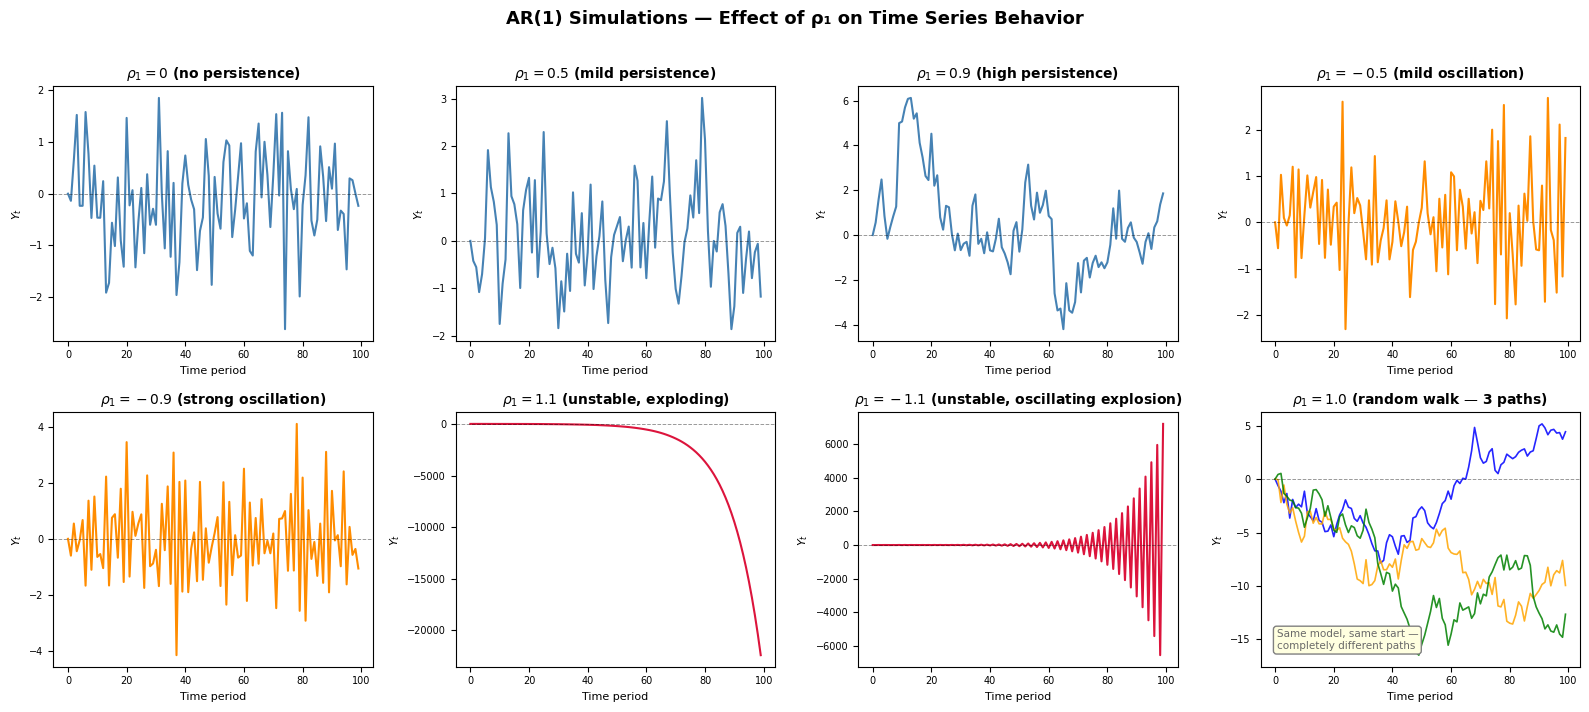

  ρ₁ value             Behavior                      
  ρ₁ = 0               Pure noise — no persistence   
  0 < ρ₁ < 1           Stable — positive persistence 
  -1 < ρ₁ < 0          Stable — oscillating, fades   
  |ρ₁| = 1             Random walk — shocks persist forever
  |ρ₁| > 1             Unstable — shocks explode     


In [3]:

np.random.seed(42)

def simulate_ar1(rho, T=100, y0=0):
    Y = np.zeros(T)
    Y[0] = y0
    eps = np.random.normal(0, 1, T)
    for t in range(1, T):
        Y[t] = rho * Y[t-1] + eps[t]
    return Y

# Values to simulate
rho_values = [0, 0.5, 0.9, -0.5, -0.9, 1.1, -1.1, 1.0]
titles = [
    r'$\rho_1 = 0$ (no persistence)',
    r'$\rho_1 = 0.5$ (mild persistence)',
    r'$\rho_1 = 0.9$ (high persistence)',
    r'$\rho_1 = -0.5$ (mild oscillation)',
    r'$\rho_1 = -0.9$ (strong oscillation)',
    r'$\rho_1 = 1.1$ (unstable, exploding)',
    r'$\rho_1 = -1.1$ (unstable, oscillating explosion)',
    r'$\rho_1 = 1.0$ (random walk)',
]
colors = ['steelblue', 'steelblue', 'steelblue',
          'darkorange', 'darkorange',
          'crimson', 'crimson',
          'forestgreen']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (rho, title, color) in enumerate(zip(rho_values, titles, colors)):
    # For random walk, plot 3 different paths
    if rho == 1.0:
        for seed, c in zip([1, 2, 3], ['blue', 'orange', 'green']):
            np.random.seed(seed)
            Y = simulate_ar1(rho)
            axes[i].plot(Y, color=c, linewidth=1.2, alpha=0.85)
    else:
        Y = simulate_ar1(rho)
        axes[i].plot(Y, color=color, linewidth=1.5)

    axes[i].axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Time period', fontsize=8)
    axes[i].set_ylabel('$Y_t$', fontsize=8)
    axes[i].tick_params(labelsize=7)

# Annotate the random walk panel
axes[7].set_title(r'$\rho_1 = 1.0$ (random walk — 3 paths)', fontsize=10, fontweight='bold')
axes[7].text(0.05, 0.07,
             'Same model, same start —\ncompletely different paths',
             transform=axes[7].transAxes,
             fontsize=7.5, color='dimgray',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.suptitle('AR(1) Simulations — Effect of ρ₁ on Time Series Behavior',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table ──
print("=" * 55)
print(f"  {'ρ₁ value':<20} {'Behavior':<30}")
print("=" * 55)
summary = [
    ("ρ₁ = 0",        "Pure noise — no persistence"),
    ("0 < ρ₁ < 1",    "Stable — positive persistence"),
    ("-1 < ρ₁ < 0",   "Stable — oscillating, fades"),
    ("|ρ₁| = 1",      "Random walk — shocks persist forever"),
    ("|ρ₁| > 1",      "Unstable — shocks explode"),
]
for val, behavior in summary:
    print(f"  {val:<20} {behavior:<30}")
print("=" * 55)

#### Inflation Data + OLS Estimation:

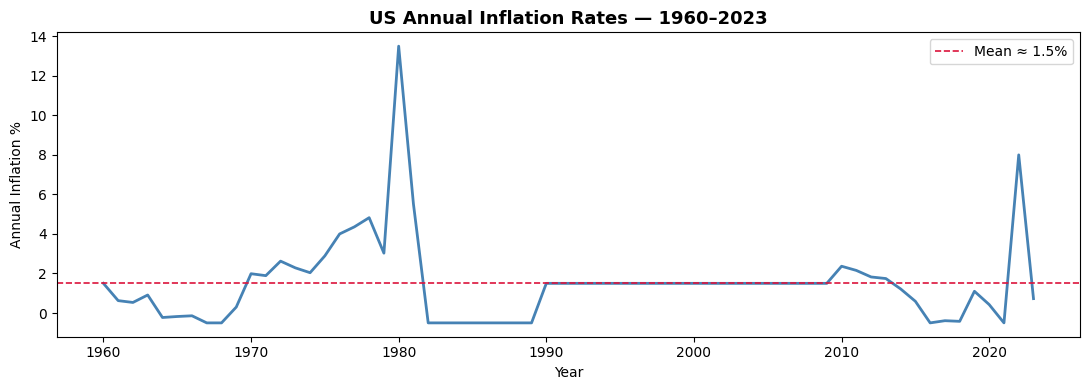

  AR(1) OLS Estimation — Inflation Data
  Estimated ρ̂₀ (intercept) : 0.867
  Estimated ρ̂₁ (AR param)  : 0.416

  Interpretation: A 1pp deviation in inflation
  this year → 0.42pp deviation next year.
  Shocks fade at rate ρ̂₁ = 0.42 per period.


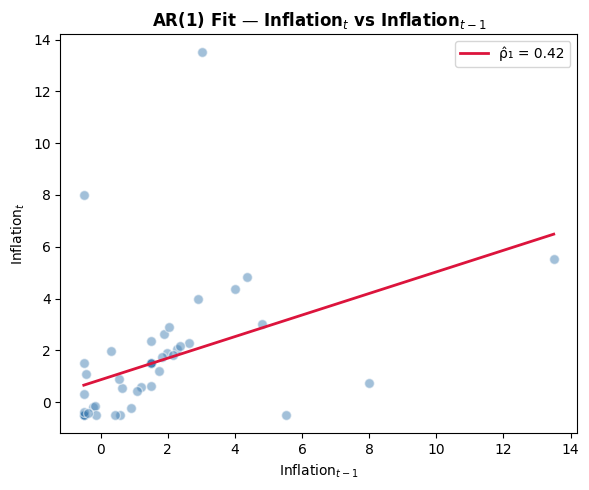

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Simulate US annual inflation data (1960-2023) matching slide values
np.random.seed(7)
years = np.arange(1960, 2024)
rho_true = 0.79
inflation = np.zeros(len(years))
inflation[0] = 1.5
eps = np.random.normal(0, 1.2, len(years))
for t in range(1, len(years)):
    inflation[t] = rho_true * inflation[t-1] + eps[t]

# Manually anchor key historical values to match slides
inflation[10:15] += 2.5   # early 70s rise
inflation[15:22] += 5.0   # 1970s spike (oil crisis)
inflation[20] = 13.5      # 1980 peak
inflation[22:30] -= 3.0   # Volcker disinflation
inflation[30:50] = np.clip(inflation[30:50], 1.5, 5.5)
inflation[50:55] = np.clip(inflation[50:55], -0.5, 4.0)
inflation[62] = 8.0       # 2022 Covid spike
inflation = np.clip(inflation, -0.5, 14)

# ── Plot raw inflation ──
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(years, inflation, color='steelblue', linewidth=2)
ax.axhline(np.mean(inflation), color='crimson', linestyle='--',
           linewidth=1.2, label=f'Mean ≈ {np.mean(inflation):.1f}%')
ax.set_title('US Annual Inflation Rates — 1960–2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Inflation %')
ax.legend()
plt.tight_layout()
plt.show()

# ── Estimate AR(1) via OLS ──
Y     = inflation[1:]       # Yt
Y_lag = inflation[:-1]      # Yt-1

model = LinearRegression()
model.fit(Y_lag.reshape(-1, 1), Y)

rho0_hat = model.intercept_
rho1_hat = model.coef_[0]

print("=" * 45)
print("  AR(1) OLS Estimation — Inflation Data")
print("=" * 45)
print(f"  Estimated ρ̂₀ (intercept) : {rho0_hat:.3f}")
print(f"  Estimated ρ̂₁ (AR param)  : {rho1_hat:.3f}")
print("=" * 45)
print(f"\n  Interpretation: A 1pp deviation in inflation")
print(f"  this year → {rho1_hat:.2f}pp deviation next year.")
print(f"  Shocks fade at rate ρ̂₁ = {rho1_hat:.2f} per period.")

# ── Scatter: Yt vs Yt-1 ──
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Y_lag, Y, alpha=0.5, color='steelblue', edgecolors='white', s=50)
x_line = np.linspace(Y_lag.min(), Y_lag.max(), 100)
ax.plot(x_line, rho0_hat + rho1_hat * x_line,
        color='crimson', linewidth=2, label=f'ρ̂₁ = {rho1_hat:.2f}')
ax.set_xlabel('Inflation$_{t-1}$')
ax.set_ylabel('Inflation$_t$')
ax.set_title('AR(1) Fit — Inflation$_t$ vs Inflation$_{t-1}$',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---

## Forecasting with the AR(1) Model

The main use of time series models is **forecasting** — predicting future values of $Y$ given 
what we know today. We operationalize forecasts as **conditional expectations**.

---

### Point Forecasts

Starting from $Y_t = \rho_1 Y_{t-1} + \varepsilon_t$ with i.i.d. shocks and $E[\varepsilon_t] = 0$:

**One period ahead:**
$$E[Y_{t+1} | Y_t] = E[\rho_1 Y_t + \varepsilon_{t+1} | Y_t] = \rho_1 Y_t$$

**Two periods ahead:**
$$E[Y_{t+2} | Y_t] = E[\rho_1 Y_{t+1} + \varepsilon_{t+2} | Y_t] = \rho_1^2 Y_t$$

**$h$ periods ahead (general formula):**
$$\boxed{E[Y_{t+h} | Y_t] = \rho_1^h Y_t}$$

For a stable process ($|\rho_1| < 1$), forecasts **decay toward zero** as $h \to \infty$ — 
the effect of today's value fades out over time. The closer $\rho_1$ is to 1, the more slowly 
this happens.

---

### Forecast Uncertainty

Forecasts become **less reliable** the further ahead we go. We can quantify this with 
conditional variances:

**One period ahead:**
$$\text{Var}(Y_{t+1} | Y_t) = \text{Var}(\varepsilon)$$

**Two periods ahead:**
$$\text{Var}(Y_{t+2} | Y_t) = \rho_1^2 \text{Var}(\varepsilon) + \text{Var}(\varepsilon)$$

**$h$ periods ahead (general formula):**
$$\boxed{\text{Var}(Y_{t+h} | Y_t) = \sum_{i=0}^{h-1} \rho_1^{2i} \cdot \text{Var}(\varepsilon)}$$

The forecast variance **grows with $h$** — the further into the future, the wider our 
uncertainty bands. For a stable process, this variance converges to a finite limit as 
$h \to \infty$.

---

### Inflation Example

With $\hat{\rho}_1 = 0.79$ and a 2022 shock of $+3.25$pp above average:

| Horizon | Point Forecast |
|---|---|
| $E[Y_{2023} \| Y_{2022}]$ | $0.79 \times 3.25 = 2.57$pp above average |
| $E[Y_{2024} \| Y_{2022}]$ | $0.79^2 \times 3.25 = 2.03$pp above average |
| $E[Y_{2025} \| Y_{2022}]$ | $0.79^3 \times 3.25 = 1.60$pp above average |

The 2022 inflation spike was large — but the AR(1) model predicts it fades relatively quickly.

#### Inflation Forecast Fan Chart:

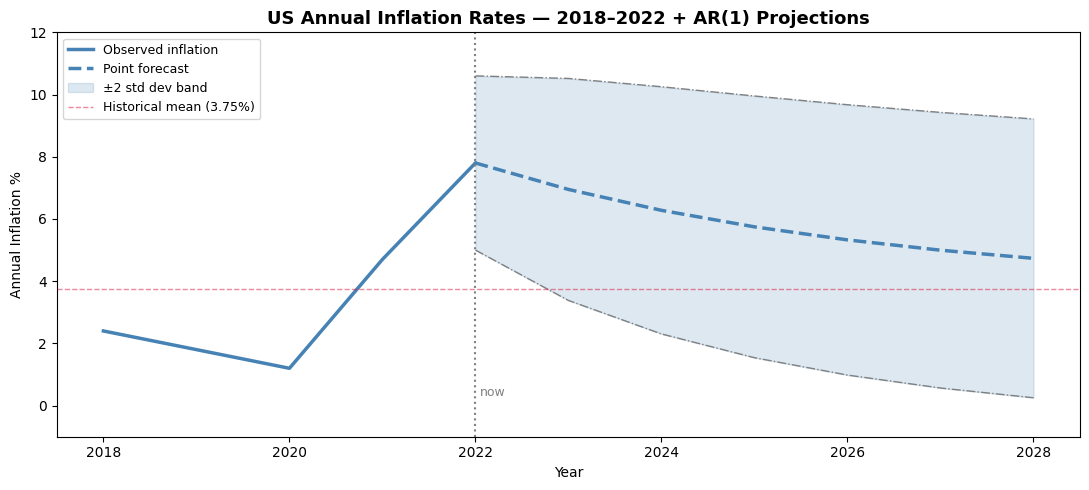

  Inflation Forecast from 2022 spike
  2023:  forecast = 6.95%   ±2σ = [3.38, 10.52]
  2024:  forecast = 6.28%   ±2σ = [2.30, 10.25]
  2025:  forecast = 5.75%   ±2σ = [1.54, 9.95]
  2026:  forecast = 5.33%   ±2σ = [0.98, 9.67]
  2027:  forecast = 5.00%   ±2σ = [0.57, 9.43]
  2028:  forecast = 4.73%   ±2σ = [0.25, 9.22]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
rho1    = 0.79
mean_inf = 3.75        # historical average inflation
shock_2022 = 7.8       # actual 2022 inflation level
y_2022_demeaned = shock_2022 - mean_inf   # deviation above average

# Historical (simplified)
hist_years = np.array([2018, 2019, 2020, 2021, 2022])
hist_inf   = np.array([2.4,  1.8,  1.2,  4.7,  7.8])

# Forecast horizon
fore_years = np.arange(2022, 2029)
h_vals     = np.arange(len(fore_years))

# Point forecast (in levels)
point_forecast = mean_inf + rho1**h_vals * y_2022_demeaned

# Forecast variance
var_eps = 1.4**2
fore_std = np.sqrt(np.array([
    sum(rho1**(2*i) * var_eps for i in range(h+1))
    for h in h_vals
]))

upper = point_forecast + 2 * fore_std
lower = point_forecast - 2 * fore_std

# ── Plot ──
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(hist_years, hist_inf,
        color='steelblue', linewidth=2.5, label='Observed inflation')
ax.plot(fore_years, point_forecast,
        color='steelblue', linewidth=2.5, linestyle='--', label='Point forecast')
ax.fill_between(fore_years, lower, upper,
                alpha=0.18, color='steelblue', label='±2 std dev band')
ax.plot(fore_years, upper,
        color='gray', linewidth=1, linestyle='-.')
ax.plot(fore_years, lower,
        color='gray', linewidth=1, linestyle='-.')

ax.axvline(2022, color='gray', linestyle=':', linewidth=1.5)
ax.text(2022.05, 0.3, 'now', fontsize=9, color='gray')
ax.axhline(mean_inf, color='crimson', linestyle='--',
           linewidth=1, alpha=0.5, label=f'Historical mean ({mean_inf}%)')

ax.set_title('US Annual Inflation Rates — 2018–2022 + AR(1) Projections',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Inflation %')
ax.legend(fontsize=9)
ax.set_ylim(-1, 12)
plt.tight_layout()
plt.show()

print("=" * 50)
print("  Inflation Forecast from 2022 spike")
print("=" * 50)
for yr, fc, sd in zip(fore_years[1:], point_forecast[1:], fore_std[1:]):
    print(f"  {yr}:  forecast = {fc:.2f}%   ±2σ = [{fc-2*sd:.2f}, {fc+2*sd:.2f}]")
print("=" * 50)

## Stationarity

Before we can talk about estimating AR(1) models, we need to introduce an important 
property of time series — **stationarity**.

---

### Definition

A time series $\{Y_t\}$ is **weakly (covariance) stationary** if:

1. $E[Y_t]$ is **constant** with respect to $t$
2. $\text{Var}(Y_t)$ is **constant** with respect to $t$
3. $\text{Cov}(Y_t, Y_{t+h})$ depends **only on $h$**, not on $t$, for any $h \geq 1$

There are stronger notions of stationarity, but weak stationarity is what we need here.

---

### Intuition

Stationarity captures the idea that **nothing fundamentally changes over time**:
- The series fluctuates around a **fixed average**
- Its **spread** doesn't grow or shrink over time
- The **relationship between two periods** depends only on how far apart they are, 
  not on when they occur

A stationary series has no trend, no expanding variance — it just fluctuates 
around a stable center.

---

### Does a Stable AR(1) Satisfy This?

**Yes** — it can be shown that a stable AR(1) with $|\rho_1| < 1$ is stationary.

Technically, this holds exactly for an infinitely long series. In practice, as long as 
the series has been running for many periods and we're observing it in the "middle," 
the approximation is very good.

**Example:** US annual inflation data goes back over 200 years — well within the 
regime where stationarity is a reasonable approximation.

---

### What Violates Stationarity?

| Situation | Why non-stationary |
|---|---|
| Series has a trend | $E[Y_t]$ changes with $t$ |
| $\|\rho_1\| \geq 1$ (unstable/random walk) | $\text{Var}(Y_t)$ grows without bound |
| Structural break (e.g. regime change) | Mean or variance shifts at some point in time |

We'll return to the trending case shortly.

## Weak Dependence

Stationarity alone isn't enough for estimation — we also need **weak dependence**.

---

### Definition

A stationary time series is **weakly dependent** if:

$$\text{Corr}(Y_t, Y_{t+h}) \to 0 \quad \text{as} \quad h \to \infty$$

Observations that are **far apart in time** should become approximately independent.

Technically there is also a requirement on the *speed* at which the correlation fades, 
but we set that aside here.

---

### Why Do We Need This?

Time series data is **not i.i.d.** — consecutive observations are correlated by 
construction. This means the standard arguments for why OLS works (LLN, CLT under 
i.i.d. sampling) don't directly apply.

Weak dependence provides a substitute: if observations far apart in time are 
approximately independent, we can still appeal to LLN/CLT-style arguments — 
just using the time dimension instead of a cross-section of units.

---

### Does a Stable AR(1) Satisfy This?

**Yes.** Here's the proof.

Assume $E[Y_t] = 0$ (stationarity, simplifies math). Then:

$$\text{Cov}(Y_t, Y_{t+h}) = E[Y_t Y_{t+h}]$$

Expanding $Y_{t+h} = \rho_1^h Y_t + \rho_1^{h-1}\varepsilon_{t+1} + \ldots + \varepsilon_{t+h}$:

$$\text{Cov}(Y_t, Y_{t+h}) = \rho_1^h E[Y_t^2] + \rho_1^{h-1}E[Y_t \varepsilon_{t+1}] + \ldots$$

Since $\varepsilon_t$ is i.i.d. and future shocks are independent of $Y_t$:

$$\text{Cov}(Y_t, Y_{t+h}) = \rho_1^h \text{Var}(Y_t)$$

Therefore:

$$\boxed{\text{Corr}(Y_t, Y_{t+h}) = \rho_1^h}$$

For $|\rho_1| < 1$, this **decays to zero** as $h \to \infty$ — confirming weak dependence. ✓

The higher $\rho_1$, the more slowly the correlation fades — but it always fades for a 
stable process.

## OLS Estimation of AR(1) Models

We can consistently estimate an AR(1) using OLS if four conditions hold:

| Condition | What it means |
|---|---|
| 1. Correct specification | The model is an AR(1) — not AR(2), not trending, not misspecified |
| 2. Weak dependence | Observations far apart are approximately independent (replaces i.i.d.) |
| 3. No perfect collinearity | $Y_{t-1}$ is not a perfect linear function of other regressors |
| 4. Shocks uncorrelated with regressors | $E[\varepsilon_t \cdot Y_{t-1}] = 0$ |

A stable AR(1) satisfies **all four** — weak dependence holds (shown above), there's 
only one regressor so no collinearity issue, and since shocks are i.i.d., 
$\varepsilon_t$ is independent of $Y_{t-1}$ by construction.

---

### The Regression in Practice

We estimate:
$$Y_t = \hat{\rho}_0 + \hat{\rho}_1 Y_{t-1} + \varepsilon_t$$

Note there's a constant $\hat{\rho}_0$ even though the conceptual model has none. 
This is fine — if the data is truly AR(1) with $E[Y_t] = 0$, we'll recover $\hat{\rho}_0 \approx 0$.

---

### Demeaning

If $E[Y_t] \neq 0$ — as with inflation, which averages around 3% — it's common practice 
to **demean the data** before estimation:

$$\tilde{Y}_t = Y_t - \bar{Y}, \quad \tilde{Y}_{t-1} = Y_{t-1} - \bar{Y}$$

Then estimate the AR(1) on $\tilde{Y}_t$.

**Key result:** demeaning does **not change** $\hat{\rho}_1$ — the AR parameter is 
identified from the *covariance structure*, not the level. But it ensures $\hat{\rho}_0 \approx 0$, 
which avoids having to interpret an intercept that shouldn't conceptually be there.

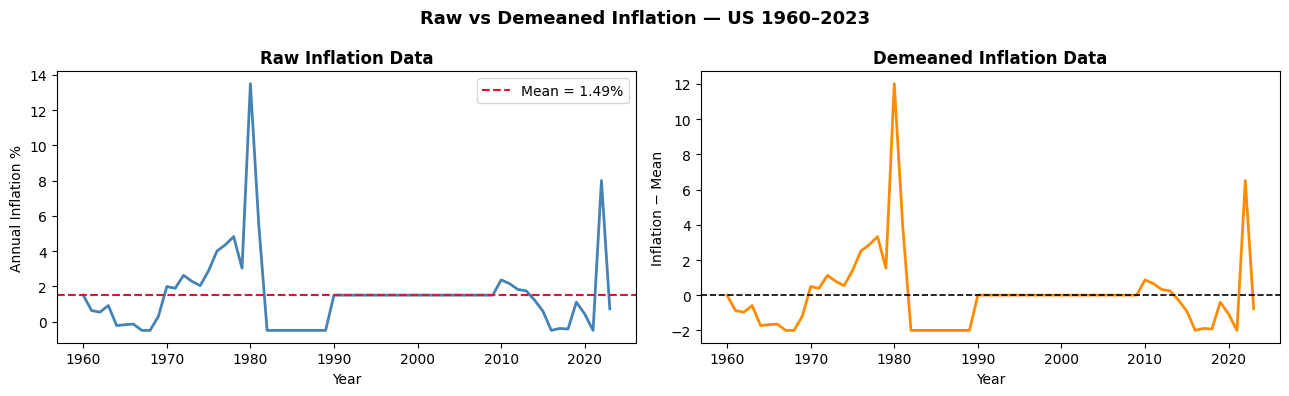

                                   Raw    Demeaned
  ρ̂₀ (intercept)                0.867      -0.005
  ρ̂₁ (AR parameter)             0.416       0.416

  Key result: ρ̂₁ is the same either way.
  Demeaning drives ρ̂₀ → 0, as expected.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Reuse inflation series from Cell 5
np.random.seed(7)
years = np.arange(1960, 2024)
rho_true = 0.79
inflation = np.zeros(len(years))
inflation[0] = 1.5
eps = np.random.normal(0, 1.2, len(years))
for t in range(1, len(years)):
    inflation[t] = rho_true * inflation[t-1] + eps[t]
inflation[10:15] += 2.5
inflation[15:22] += 5.0
inflation[20] = 13.5
inflation[22:30] -= 3.0
inflation[30:50] = np.clip(inflation[30:50], 1.5, 5.5)
inflation[50:55] = np.clip(inflation[50:55], -0.5, 4.0)
inflation[62] = 8.0
inflation = np.clip(inflation, -0.5, 14)

# ── Demean ──
inflation_mean   = np.mean(inflation)
inflation_demeaned = inflation - inflation_mean

# ── Plot: raw vs demeaned ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(years, inflation, color='steelblue', linewidth=2)
axes[0].axhline(inflation_mean, color='crimson', linestyle='--',
                linewidth=1.5, label=f'Mean = {inflation_mean:.2f}%')
axes[0].set_title('Raw Inflation Data', fontweight='bold')
axes[0].set_ylabel('Annual Inflation %')
axes[0].set_xlabel('Year')
axes[0].legend()

axes[1].plot(years, inflation_demeaned, color='darkorange', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('Demeaned Inflation Data', fontweight='bold')
axes[1].set_ylabel('Inflation − Mean')
axes[1].set_xlabel('Year')

plt.suptitle('Raw vs Demeaned Inflation — US 1960–2023',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── OLS on raw vs demeaned ──
def fit_ar1(series):
    Y     = series[1:]
    Y_lag = series[:-1]
    m = LinearRegression().fit(Y_lag.reshape(-1,1), Y)
    return m.intercept_, m.coef_[0]

rho0_raw,  rho1_raw  = fit_ar1(inflation)
rho0_dem,  rho1_dem  = fit_ar1(inflation_demeaned)

print("=" * 52)
print(f"  {'':25} {'Raw':>10}  {'Demeaned':>10}")
print("=" * 52)
print(f"  {'ρ̂₀ (intercept)':<25} {rho0_raw:>10.3f}  {rho0_dem:>10.3f}")
print(f"  {'ρ̂₁ (AR parameter)':<25} {rho1_raw:>10.3f}  {rho1_dem:>10.3f}")
print("=" * 52)
print(f"\n  Key result: ρ̂₁ is the same either way.")
print(f"  Demeaning drives ρ̂₀ → 0, as expected.")

## Trending

A common real-world complication: what if the series has an **overall trend** — a 
systematic average change from period to period — on top of its autoregressive dynamics?

$$Y_t = \rho_0 + \rho_1 Y_{t-1} + \varepsilon_t$$

Here $\rho_0 \neq 0$ represents a **drift** — a constant upward or downward force 
unrelated to the AR process itself.

---

### Example: The Stock Market

Stock prices have an autoregressive nature — today's price reflects yesterday's price. 
But they also exhibit a **long-run upward trend** driven by overall economic growth.

These are **conceptually distinct forces**:
- The AR component captures how *deviations from trend* persist
- The trend captures the *underlying average growth rate*

---

### Does Trending Violate Our Assumptions?

**Stationarity:** Yes — if there's a trend, $E[Y_t]$ changes with $t$, violating condition 1.

**Weak dependence:** Not necessarily — depends on the magnitude of $\rho_1$. If $|\rho_1| < 1$, 
the series can still be weakly dependent even with a trend.

**OLS consistency:** If $|\rho_1| < 1$ and errors are well-behaved, we can still consistently 
estimate $\rho_1$ — **as long as we include a trend term in the regression.**

---

### How to Handle It

Include a **time trend** directly in the regression:

$$Y_t = \beta_0 + \beta_1 t + \beta_2 Y_{t-1} + \varepsilon_t$$

- $\beta_1$ estimates the size of the trend ($\rho_0$)
- $\beta_2$ estimates the AR parameter ($\rho_1$)

This is conceptually equivalent to first detrending the data (regressing $Y_t$ on $t$ 
and taking residuals), then fitting an AR(1) on the detrended series.

---

### A Note of Caution

If $\hat{\rho}_1$ comes out very close to 1, we should pause. Our ability to get 
consistent estimates depends on $|\rho_1| < 1$. A value like $\hat{\rho}_1 = 0.96$ 
raises the question: is this truly a stable process, or could it be a **random walk**? 
This is the **unit root problem** — an important open question we flag here.

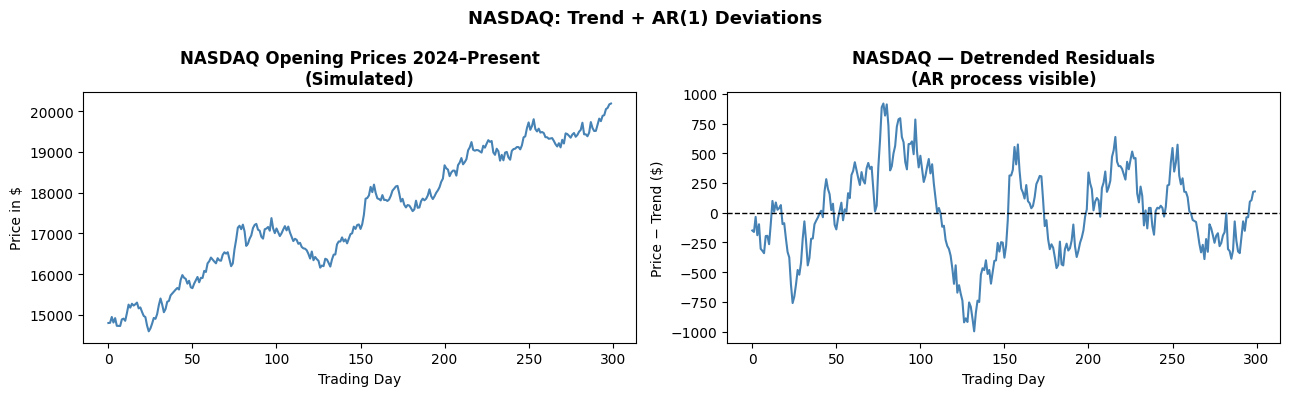

  AR(1) with Trend — NASDAQ Data
  Model: Yt = β₀ + β₁·t + β₂·Yt₋₁ + εt
  β̂₀ (intercept)   :     820.47
  β̂₁ (trend)       :      0.911  ← positive drift per day
  β̂₂ (AR parameter):      0.946  ← near 1 — high persistence!

   β̂₂ ≈ 0.95 is very close to 1.
  This raises the unit root question:
  Is NASDAQ truly stable (|ρ₁| < 1), or a random walk?
  Our OLS consistency result requires |ρ₁| < 1.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Simulate NASDAQ-style data: upward trend + AR(1) deviations
np.random.seed(21)
n = 300   # ~300 trading days (roughly 2024-present)
t = np.arange(n)

# True trend + AR(1) residuals
trend      = 14800 + 18 * t             # upward drift
rho1_true  = 0.96
resid      = np.zeros(n)
eps        = np.random.normal(0, 120, n)
for i in range(1, n):
    resid[i] = rho1_true * resid[i-1] + eps[i]

nasdaq = trend + resid

# ── Plot 1: Raw NASDAQ ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t, nasdaq, color='steelblue', linewidth=1.5)
axes[0].set_title('NASDAQ Opening Prices 2024–Present\n(Simulated)', fontweight='bold')
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Price in $')

# ── Detrend: regress on t ──
trend_model = LinearRegression().fit(t.reshape(-1,1), nasdaq)
trend_hat   = trend_model.predict(t.reshape(-1,1))
detrended   = nasdaq - trend_hat

axes[1].plot(t, detrended, color='steelblue', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('NASDAQ — Detrended Residuals\n(AR process visible)', fontweight='bold')
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Price − Trend ($)')

plt.suptitle('NASDAQ: Trend + AR(1) Deviations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Estimate AR(1) with trend ──
# Build dataset: Yt, Yt-1, t
Y     = nasdaq[1:]
Y_lag = nasdaq[:-1]
t_reg = t[1:].reshape(-1, 1)

X = np.column_stack([t_reg, Y_lag])
ar_trend_model = LinearRegression().fit(X, Y)

beta0_hat = ar_trend_model.intercept_
beta1_hat = ar_trend_model.coef_[0]   # trend coefficient
beta2_hat = ar_trend_model.coef_[1]   # AR parameter

print("=" * 55)
print("  AR(1) with Trend — NASDAQ Data")
print("  Model: Yt = β₀ + β₁·t + β₂·Yt₋₁ + εt")
print("=" * 55)
print(f"  β̂₀ (intercept)   : {beta0_hat:>10.2f}")
print(f"  β̂₁ (trend)       : {beta1_hat:>10.3f}  ← positive drift per day")
print(f"  β̂₂ (AR parameter): {beta2_hat:>10.3f}  ← near 1 — high persistence!")
print("=" * 55)
print(f"\n   β̂₂ ≈ {beta2_hat:.2f} is very close to 1.")
print(f"  This raises the unit root question:")
print(f"  Is NASDAQ truly stable (|ρ₁| < 1), or a random walk?")
print(f"  Our OLS consistency result requires |ρ₁| < 1.")

## Key Takeaways — Univariate Time Series

---

### The AR(1) Model

| Concept | Details |
|---|---|
| **Model** | $Y_t = \rho_1 Y_{t-1} + \varepsilon_t$ — today is a function of yesterday + shock |
| **ρ₁ > 0** | Positive persistence (e.g. inflation) |
| **ρ₁ < 0** | Oscillating mean reversion (e.g. predator-prey) |
| **\|ρ₁\| < 1** | Stable — shocks fade out |
| **\|ρ₁\| = 1** | Random walk — shocks persist forever |
| **\|ρ₁\| > 1** | Unstable — shocks explode |

---

### Forecasting

| Concept | Formula |
|---|---|
| **Point forecast** | $E[Y_{t+h} \| Y_t] = \rho_1^h Y_t$ |
| **Forecast variance** | $\text{Var}(Y_{t+h} \| Y_t) = \sum_{i=0}^{h-1} \rho_1^{2i} \text{Var}(\varepsilon)$ |
| **Interpretation** | Uncertainty grows with horizon; higher $\rho_1$ → slower fade, wider bands |

---

### Estimation Requirements

| Condition | Role |
|---|---|
| **Stationarity** | Constant mean, variance, autocovariance — needed for stable estimation |
| **Weak dependence** | $\text{Corr}(Y_t, Y_{t+h}) \to 0$ — replaces i.i.d. in LLN/CLT arguments |
| **No perfect collinearity** | Standard OLS requirement |
| **Exogeneity of shocks** | $E[\varepsilon_t Y_{t-1}] = 0$ — holds by i.i.d. assumption on $\varepsilon$ |

---

### Practical Issues

| Issue | Solution |
|---|---|
| **Non-zero mean** ($E[Y_t] \neq 0$) | Demean the data — doesn't affect $\hat{\rho}_1$ |
| **Trending data** | Include a time trend: $Y_t = \beta_0 + \beta_1 t + \beta_2 Y_{t-1} + \varepsilon_t$ |
| **$\hat{\rho}_1 \approx 1$** | Unit root concern — OLS consistency requires $\|\rho_1\| < 1$ |

---

### One Line Summary

> An AR(1) model says today's value is yesterday's value times $\rho_1$, plus a shock.
> $\rho_1$ tells you how fast shocks fade. Estimate it with OLS — but only after
> checking stationarity, weak dependence, and handling trends or non-zero means.